# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [29]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [30]:
# Inspect the shapes of the datasets
print("X_train shape:", X_train.shape) 
print("y_train shape:", y_train.shape)   
print("X_test shape:", X_test.shape)     
print("y_test shape:", y_test.shape) 

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [31]:
# Convert labels to one-hot encoding
import numpy as np
from tensorflow.keras.utils import to_categorical

def one_hot(n_classes, y):
    return np.eye(n_classes)[y]

y_train = one_hot(10, y_train)
y_test = one_hot(10, y_test)


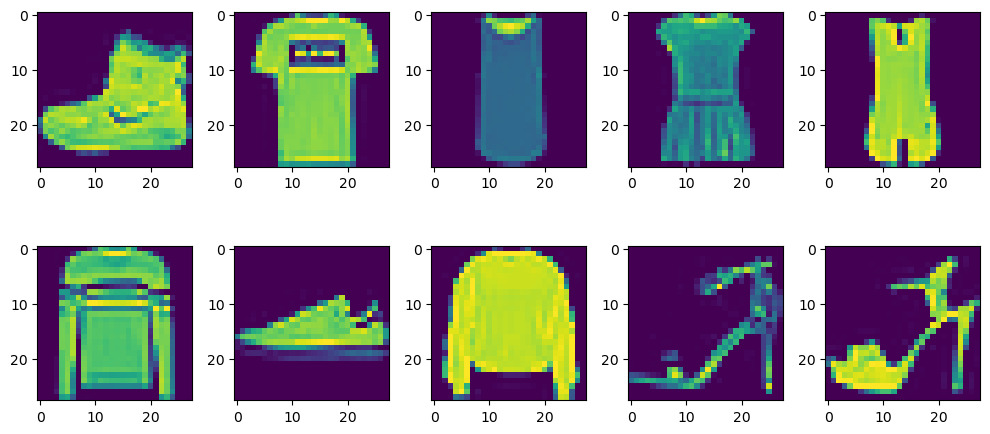

In [32]:
import matplotlib.pyplot as plt
# Verify the data looks as expected
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28))
plt.tight_layout()
plt.show()

# struggled with this one a lot.

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

10 images of apparel items as expected, each image is 28x28 as expected and coded.
Images are not greyscale (I tried to add cmap=plt.cm.gray_r but it was not working).
Images are very low quality.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [33]:
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.optimizers import SGD, Adam

# Create a simple linear regression model
model = Sequential()

# You can use `model.add(<layer>)` to add layers to the model
model.add(Flatten(input_shape=(28, 28, 1)))
model.add(Dense(64, activation='relu', input_shape=(64,)))  
model.add(Dense(64, activation='relu'))  
model.add(Dense(10, activation='softmax'))  

# Compile the model using `model.compile()`
model.compile(
    loss='categorical_crossentropy',  
    optimizer=SGD(learning_rate=0.01),  
    metrics=['accuracy']
)

# Train the model with `model.fit()`
model.fit(
    X_train, 
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)



Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6110 - loss: 1.1775 - val_accuracy: 0.7938 - val_loss: 0.5801
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8135 - loss: 0.5413 - val_accuracy: 0.8270 - val_loss: 0.4968
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8332 - loss: 0.4795 - val_accuracy: 0.8229 - val_loss: 0.4968
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8424 - loss: 0.4459 - val_accuracy: 0.8427 - val_loss: 0.4500
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8526 - loss: 0.4258 - val_accuracy: 0.8533 - val_loss: 0.4162
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8548 - loss: 0.4079 - val_accuracy: 0.8564 - val_loss: 0.4145
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8608 - loss: 0.3951 - val_accuracy: 0.8582 - val_loss: 0.4080
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8666 - loss: 0.3784 - 

In [34]:
# Evaluate the model with `model.evaluate()`

loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8622 - loss: 0.3937
Loss:     0.40
Accuracy: 85.89%


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

The baseline model has an 86% accuracy with a loss of 0.40. This is better than what I was expecting, especially given that we coverted the 2D images into 1D vectors.
I expected the model to struggle a lot more with like for like tops (it probably did contribute to a lesser accuracy).

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [35]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))  


# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.01),
    metrics=['accuracy']
)

# Train the model with `model.fit()`
model.fit(
    X_train, 
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 90s 57ms/step - accuracy: 0.8009 - loss: 0.6297 - val_accuracy: 0.8684 - val_loss: 0.3718
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 77s 51ms/step - accuracy: 0.8852 - loss: 0.3146 - val_accuracy: 0.8651 - val_loss: 0.3709
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 56ms/step - accuracy: 0.9026 - loss: 0.2638 - val_accuracy: 0.8779 - val_loss: 0.3488
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 88s 59ms/step - accuracy: 0.9098 - loss: 0.2381 - val_accuracy: 0.8820 - val_loss: 0.3765
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 55ms/step - accuracy: 0.9223 - loss: 0.2056 - val_accuracy: 0.8664 - val_loss: 0.4571
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 53ms/step - accuracy: 0.9267 - loss: 0.1948 - val_accuracy: 0.8757 - val_loss: 0.4645
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 100s 66ms/step - accuracy: 0.9343 - loss: 0.1756 - val_accuracy: 0.8774 - val_loss: 0.5140
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 103s 68ms/step - accuracy: 0.9425

In [36]:
# Evaluate the model with `model.evaluate()`

loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8726 - loss: 0.6977
Loss:     0.68
Accuracy: 87.51%


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

The CNN model was only slighly more accurate than our baseline model (88%). The increase in accuracy can be attributed to ReLU which better allows for non-linear learning. Adam may have also contributed to this as it automatically adjusts the learning rate based on how the training is going. I was expecting a higher level of accuracy for the CNN model.

We saw more loss with the CNN model as well, which may be a sign of overfitting or just a result of running a more complex model (or I made a mistake somewhere). 

# 4. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [39]:
# A. Test Hyperparameters - adding a new dropout layer
from keras.layers import Dropout


# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model w dropout layer
model_dropout = Sequential()
model_dropout.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model_dropout.add(Flatten())
model_dropout.add(Dense(64, activation='relu'))
model_dropout.add(Dropout(0.3))
model_dropout.add(Dense(10, activation='softmax'))  


# Compile the model
model_dropout.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.01),
    metrics=['accuracy']
)

# Train the model with `model.fit()`
history = model_dropout.fit(
    X_train, 
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


c:\Users\aakav\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.7845 - loss: 0.6712 - val_accuracy: 0.8550 - val_loss: 0.3996
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.8603 - loss: 0.3851 - val_accuracy: 0.8819 - val_loss: 0.3513
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.8762 - loss: 0.3392 - val_accuracy: 0.8785 - val_loss: 0.3587
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 89s 59ms/step - accuracy: 0.8815 - loss: 0.3202 - val_accuracy: 0.8817 - val_loss: 0.3606
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 113s 75ms/step - accuracy: 0.8908 - loss: 0.2922 - val_accuracy: 0.8661 - val_loss: 0.4041
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 89s 60ms/step - accuracy: 0.8980 - loss: 0.2712 - val_accuracy: 0.8848 - val_loss: 0.3871
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 76s 51ms/step - accuracy: 0.9052 - loss: 0.2607 - val_accuracy: 0.8709 - val_loss: 0.4568
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 56ms/step - accuracy: 0.9103 

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8656 - loss: 0.5938
Loss:     0.57
Accuracy: 86.82%


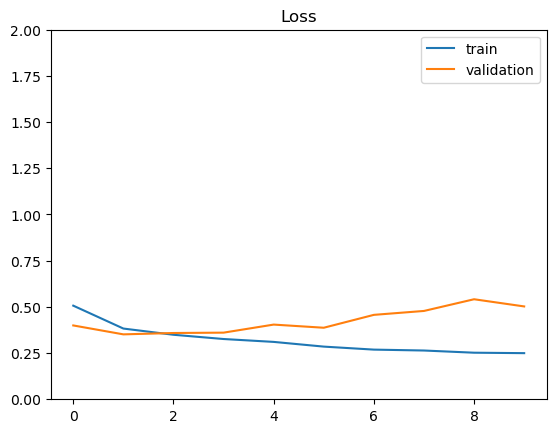

In [40]:
# B. Test presence or absence of regularization

loss, accuracy = model_dropout.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.ylim(0, 2)
plt.legend(loc='best')
plt.title('Loss');


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

The only change I made was adding a addiitonal layer, in which I introduced a dropout of 0.3. This  reduced the performance of our model. Not only did it reduce the accuracy of our model slightly, but it also substantially slowed down the model training process. While the loss in this model is less, it is clear that overfitting is likely not a significant issue with the CNN model. 

In my final model (b), I will try to improve the performance by increasing the filter count and removing the dropout layer.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [45]:
# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create the final  CNN model w greater kernel size, greater dense layer size, greater filter count and no dropout
model_final = Sequential()
model_final.add(Conv2D(64, kernel_size=(5, 5), activation='relu', input_shape=(28, 28, 1)))
model_final.add(Flatten())
model_final.add(Dense(128, activation='relu'))  
model_final.add(Dense(10, activation='softmax'))  


# Compile the model
model_final.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.01),
    metrics=['accuracy']
)

# Train the model with `model.fit()`
history_final = model_final.fit(
    X_train, 
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

c:\Users\aakav\miniconda3\envs\dsi_participant\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 238s 157ms/step - accuracy: 0.7991 - loss: 0.6204 - val_accuracy: 0.8612 - val_loss: 0.3850
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 141s 94ms/step - accuracy: 0.8740 - loss: 0.3441 - val_accuracy: 0.8605 - val_loss: 0.3819
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 119s 79ms/step - accuracy: 0.8871 - loss: 0.3068 - val_accuracy: 0.8725 - val_loss: 0.3713
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 197s 116ms/step - accuracy: 0.9011 - loss: 0.2636 - val_accuracy: 0.8746 - val_loss: 0.4110
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 160s 107ms/step - accuracy: 0.9135 - loss: 0.2364 - val_accuracy: 0.8673 - val_loss: 0.4626
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 120s 80ms/step - accuracy: 0.9177 - loss: 0.2217 - val_accuracy: 0.8691 - val_loss: 0.4648
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 122s 81ms/step - accuracy: 0.9287 - loss: 0.1915 - val_accuracy: 0.8737 - val_loss: 0.5910
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 122s 81ms/step - accurac

In [46]:
loss, accuracy = model_final.evaluate(X_test, y_test)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.8674 - loss: 0.7825
Loss:     0.75
Accuracy: 86.89%


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

Baseline Model
- Loss:     0.40
- Accuracy: 85.89%

Original CNN
- Loss:     0.68
- Accuracy: 87.51%

Final CNN
Loss:     0.75
Accuracy: 86.89%



The final model is performs more accurately than the baseline model but surprisingly less accurately than the original CNN model, but all models are only marginally different in accuracy. Despite the final CNN model has more filters, larger kernels, and a bigger dense layer, the results do not show an improvement to accuracy or loss. The key trade off is that the final model took 26 minutes to train, whereas the baseline model only took 1 minute and the first CNN took 15 minutes.



🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.